## Ejemplo de clustering con distribuciones usando distancia de Wasserstein (baloncesto: perfiles de tiro)

En muchos problemas deportivos, cada entidad (jugador/equipo) no se describe bien con un vector “plano”, sino con una **distribución**: p. ej., la distribución de distancia de tiro, zonas de tiro (heatmap), velocidades en carrera, etc. En estos casos, métricas tipo **Wasserstein / Earth Mover’s Distance (EMD)** son muy interpretables: miden “cuánto hay que mover la masa” para transformar una distribución en otra.

---

### 1) Definición (1D)

Sea $p$ y $q$ dos distribuciones sobre la recta real (p. ej., distancia al aro). La **Wasserstein-1** se define como el coste mínimo de transporte:

$$W_1(p,q)=\inf_{\pi\in\Pi(p,q)}\int_{\mathbb{R}\times\mathbb{R}} |x-y|\; d\pi(x,y),$$

donde $\Pi(p,q)$ es el conjunto de “planes de transporte” (acoplamientos) con marginales $p$ y $q$. (Intuición: $\pi(x,y)$ dice cuánta masa se mueve de $x$ a $y$).

**Resultado clave en 1D**: si $F_p$ y $F_q$ son las CDFs de $p$ y $q$,

$$W_1(p,q)=\int_{-\infty}^{\infty} \big|F_p(t)-F_q(t)\big|\;dt.$$

Es decir: el área entre las dos CDFs.

---

### 2) Caso discreto en bins ordenados

Supón un histograma con $B$ bins ordenados, de ancho $\Delta$, y probabilidades:

$$\mathbf{p}=(p_1,\dots,p_B),\quad \mathbf{q}=(q_1,\dots,q_B),\quad \sum_i p_i=\sum_i q_i=1.$$

Define las acumuladas:

$$P_i=\sum_{j=1}^{i} p_j,\qquad Q_i=\sum_{j=1}^{i} q_j.$$

Entonces, una forma estándar de calcular $W_1$ en 1D (discreto) es:

$$W_1(\mathbf{p},\mathbf{q}) \approx \Delta\sum_{i=1}^{B-1}\left|P_i-Q_i\right|.$$

Interpretación: en cada “corte” entre bins, $|P_i-Q_i|$ es el **exceso de masa** que debe cruzar ese corte; sumar esos excesos (y multiplicar por el ancho) da el coste total.

---

## 3) Dataset deportivo: tiros en la NBA y clustering por “perfil de distancia”

Usaremos tiros vía el endpoint `shotchartdetail` del paquete `nba_api` (cliente de la API pública de stats).

### Idea
1) Para cada jugador, construimos su distribución $p$ de **distancia de tiro** (histograma normalizado).
2) Calculamos una matriz de distancias $D_{ab}=W_1(p_a,p_b)$.
3) Hacemos clustering (p. ej., jerárquico con enlace promedio) usando $D$.

### 3.1 Código (Python) — construir distribuciones y distancias Wasserstein

In [2]:
# pip install nba_api pandas numpy scipy scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

In [17]:

# ---Elegimos jugadores (ejemplo) ---
names = ["Stephen Curry", "Kevin Durant", "Giannis Antetokounmpo"]
names = [
    "Stephen Curry",
    "Klay Thompson",
    "Damian Lillard",
    "Trae Young",
    "James Harden",
    "Kyrie Irving",
    "Devin Booker",
    "Kevin Durant",
    "LeBron James",
    "Jayson Tatum",
    "DeMar DeRozan",
    "Anthony Edwards",
    "Shai Gilgeous-Alexander",
    "Kawhi Leonard",
    "Paul George",
    "Joel Embiid",
    "Giannis Antetokounmpo",
    "Anthony Davis",
    "Bam Adebayo",
    "Rudy Gobert",
    "Victor Wembanyama"
]

player_dict = players.get_players()
name_to_id = {p["full_name"]: p["id"] for p in player_dict}

player_ids = [name_to_id[n] for n in names]


In [18]:

# --- Descargamos tiros de una temporada (ejemplo) ---
season = "2023-24"

def get_shots(player_id):
    sc = shotchartdetail.ShotChartDetail(
        team_id=0,
        player_id=player_id,
        season_nullable=season,
        season_type_all_star="Regular Season",
        context_measure_simple="FGA"
    )
    # Devuelve un dataframe con columnas como SHOT_DISTANCE, LOC_X, LOC_Y, etc.
    return sc.get_data_frames()[0]

shots = []
for pid, n in zip(player_ids, names):
    df = get_shots(pid)
    df["player"] = n
    shots.append(df[["player", "SHOT_DISTANCE"]].dropna())
shots = pd.concat(shots, ignore_index=True)

# --- Convertir a histogramas (distribuciones) ---
# bins en pies (SHOT_DISTANCE está en feet)
bin_edges = np.array([0, 4, 8, 12, 16, 20, 24, 28, 35, 60])  # último para tiros muy largos
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
B = len(bin_centers)

def hist_prob(distances):
    h, _ = np.histogram(distances, bins=bin_edges)
    h = h.astype(float)
    return h / h.sum()

H = {}
for n in names:
    H[n] = hist_prob(shots.loc[shots["player"] == n, "SHOT_DISTANCE"].values)

# --- Distancia Wasserstein entre histogramas (usando scipy con pesos) ---
# Para histogramas: usar "posiciones" = centros de bin y "weights" = probabilidades
def W1_hist(p, q):
    return wasserstein_distance(bin_centers, bin_centers, u_weights=p, v_weights=q)

D = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        D.loc[a, b] = W1_hist(H[a], H[b])

print("Matriz de distancias W1 (en feet):")
print(D.round(2))

Matriz de distancias W1 (en feet):
                         Stephen Curry  Klay Thompson  Damian Lillard  \
Stephen Curry                     0.00           1.58            2.73   
Klay Thompson                     1.58           0.00            3.87   
Damian Lillard                    2.73           3.87            0.00   
Trae Young                        2.56           3.86            1.27   
James Harden                      1.42           2.03            1.98   
Kyrie Irving                      4.76           5.25            2.70   
Devin Booker                      4.41           4.90            2.91   
Kevin Durant                      4.88           5.36            3.75   
LeBron James                      8.27           8.75            5.61   
Jayson Tatum                      4.41           4.89            1.74   
DeMar DeRozan                     6.76           7.25            4.36   
Anthony Edwards                   5.67           6.20            2.97   
Shai Gilgeous-Al

Hay que desplazar masa de la distribución unos ~3.5 pies de media acumulada (según el transporte óptimo)

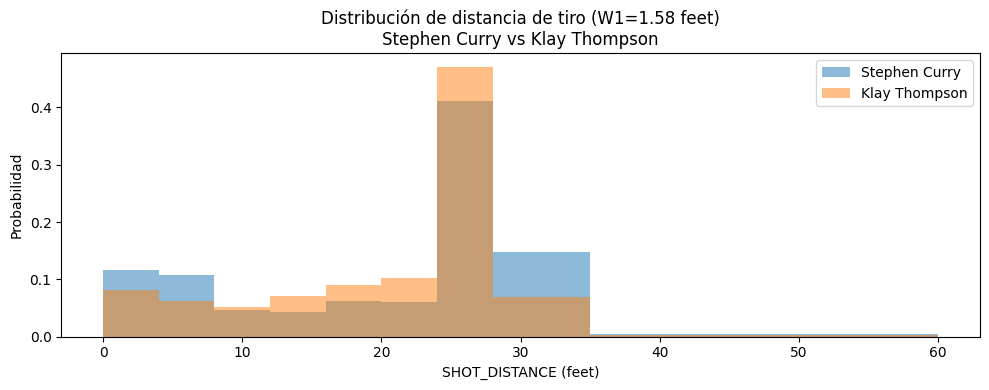

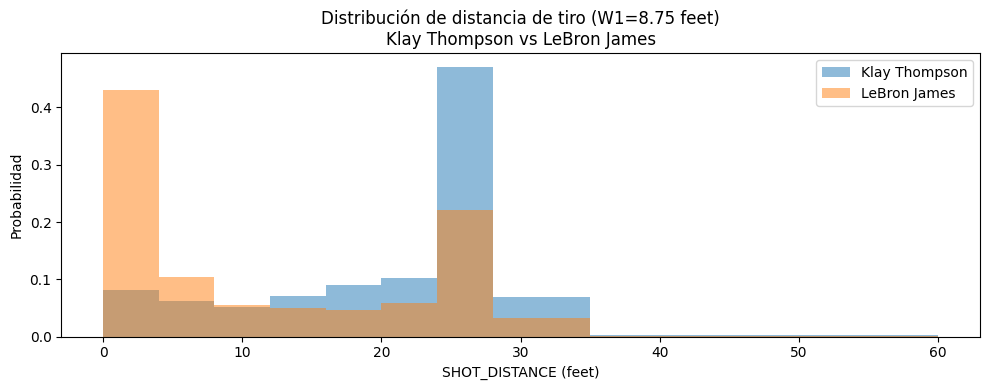

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

bin_edges = np.array([0, 4, 8, 12, 16, 20, 24, 28, 35, 60])
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

def hist_prob(distances):
    h, _ = np.histogram(distances, bins=bin_edges)
    h = h.astype(float)
    return h / h.sum() if h.sum() > 0 else np.ones(len(bin_centers)) / len(bin_centers)

def W1_hist(p, q):
    return wasserstein_distance(bin_centers, bin_centers, u_weights=p, v_weights=q)

def plot_pair_hist(player_a, player_b, shots_df):
    da = shots_df.loc[shots_df["player"] == player_a, "SHOT_DISTANCE"].dropna().values
    db = shots_df.loc[shots_df["player"] == player_b, "SHOT_DISTANCE"].dropna().values

    pa = hist_prob(da)
    pb = hist_prob(db)

    w1 = W1_hist(pa, pb)

    width = np.diff(bin_edges)  # ancho por bin (para el bar)
    lefts = bin_edges[:-1]

    plt.figure(figsize=(10, 4))
    plt.bar(lefts, pa, width=width, align="edge", alpha=0.5, label=player_a)
    plt.bar(lefts, pb, width=width, align="edge", alpha=0.5, label=player_b)
    plt.title(f"Distribución de distancia de tiro (W1={w1:.2f} feet)\n{player_a} vs {player_b}")
    plt.xlabel("SHOT_DISTANCE (feet)")
    plt.ylabel("Probabilidad")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 1) Curry vs Klay
plot_pair_hist("Stephen Curry", "Klay Thompson", shots)

# 2) Klay vs LeBron
plot_pair_hist("Klay Thompson", "LeBron James", shots)


## Clustering con distancia precomputada (jerárquico)

In [19]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# linkage necesita distancias en formato condensado
condensed = squareform(D.values, checks=False)

Z = linkage(condensed, method="average")  # enlace promedio
labels = fcluster(Z, t=2, criterion="maxclust")  # p.ej., 2 clusters

out = pd.DataFrame({"player": names, "cluster": labels}).sort_values("cluster")
print(out)


                     player  cluster
19              Rudy Gobert        1
18              Bam Adebayo        1
17            Anthony Davis        1
16    Giannis Antetokounmpo        1
0             Stephen Curry        2
1             Klay Thompson        2
2            Damian Lillard        2
3                Trae Young        2
8              LeBron James        2
9              Jayson Tatum        2
10            DeMar DeRozan        2
11          Anthony Edwards        2
4              James Harden        2
5              Kyrie Irving        2
6              Devin Booker        2
7              Kevin Durant        2
15              Joel Embiid        2
14              Paul George        2
13            Kawhi Leonard        2
12  Shai Gilgeous-Alexander        2
20        Victor Wembanyama        2


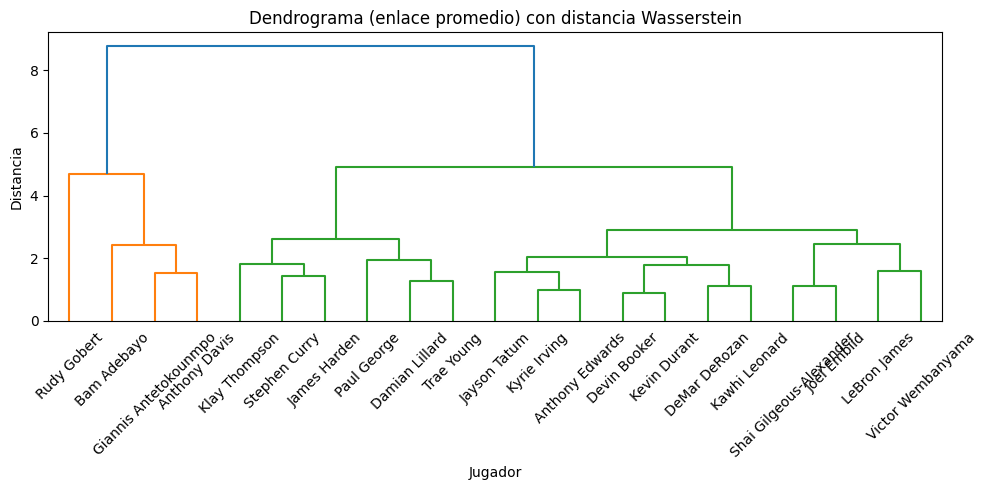

In [20]:
plt.figure(figsize=(10, 5))
dendrogram(
    Z,
    labels=names,          # nombres en el eje
    leaf_rotation=45,      # gira etiquetas
    leaf_font_size=10,
    color_threshold=None   # si quieres colorear por un umbral, pon un número aquí
)
plt.title("Dendrograma (enlace promedio) con distancia Wasserstein")
plt.xlabel("Jugador")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()


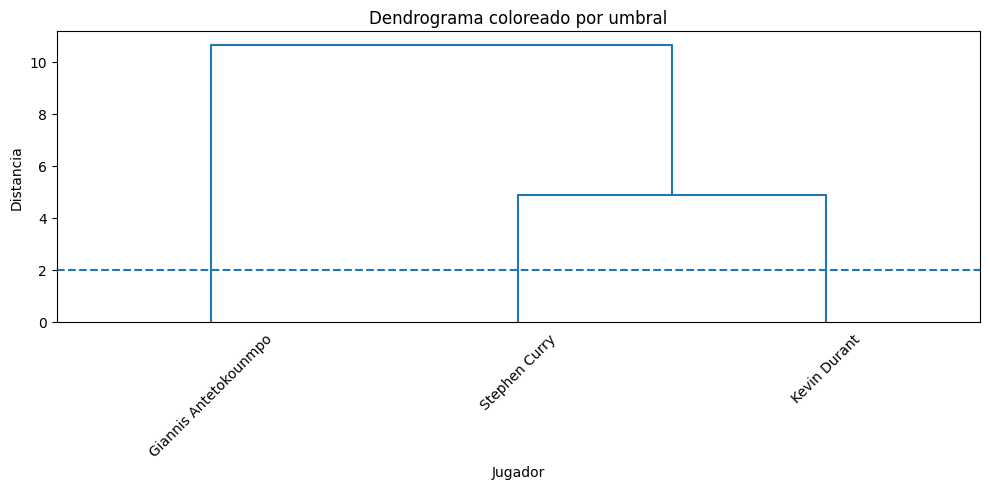

In [12]:
threshold = 2.0
plt.figure(figsize=(10, 5))
dendrogram(
    Z,
    labels=names,
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=threshold
)
plt.axhline(threshold, linestyle="--")
plt.title("Dendrograma coloreado por umbral")
plt.xlabel("Jugador")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()


### Variante streaming sobre distribuciones: ventanas vs actualización online (decaimiento)

Supongaamos que tenemos, para cada jugador, una distribución $\mathbf{p} $ (histograma normalizado) de distancia de tiro. A medida que llegan nuevos datos (partido a partido), podemos actualizar esa distribución de dos formas:

#### (a) Ventana deslizante (sliding window)
Mantenemos solo los últimos $W$ tiros (o los tiros de los últimos $K$ partidos) y reconstruimos el histograma:

- En el instante $t$, tomamos el conjunto $ \{d_{t-W+1}, \dots, d_t\} $
- Calculamos $ \widehat{\mathbf{p}}^{(t)} $ con `np.histogram(...)` y normalizamos para que sume 1

**Pros:** refleja muy bien el “perfil reciente”.
**Contras:** recalcular desde cero cada vez cuesta más y depende mucho de $W$.

---

#### (b) Actualización online con decaimiento exponencial
Mantenemos un histograma “vivo” $ \mathbf{p}^{(t)}$ y, cuando llega un nuevo micro-lote (p. ej., tiros de un partido), calculamos su histograma normalizado $\widehat{\mathbf{p}}_{\text{nuevo}}$ y actualizamos:

$$\mathbf{p}^{(t)} \leftarrow (1-\alpha)\,\mathbf{p}^{(t-1)} + \alpha\,\widehat{\mathbf{p}}_{\text{nuevo}},
\qquad \alpha \in (0,1)$$

- Si $\alpha$ es pequeño (p. ej., 0.05): olvidamos despacio, perfil más estable.
- Si $\alpha$ es grande (p. ej., 0.3): nos adaptamos rápido, perfil más reactivo.

Después de actualizar, (opcional pero recomendable) renormalizamos para asegurar $\sum_i p_i = 1$.

---

#### ¿Qué hacer con $W_1$ (Wasserstein) en streaming?
En cada actualización (cada partido o cada bloque de tiros) podemos:

1) **Monitorizar deriva**: calcular $W_1(\mathbf{p}^{(t)}, \mathbf{p}^{(t-1)})$.
   - Si crece, el perfil de tiro está cambiando.

2) **Asignación a prototipos** (clustering “semi-online”):
   - Tenemos prototipos/centroides/medoids $\{\mathbf{c}_1,\dots,\mathbf{c}_k\}$ (calculados offline o actualizados por ventanas)
   - Asignamos el jugador al clúster:
$$\arg\min_j W_1(\mathbf{p}^{(t)}, \mathbf{c}_j)$$

3) **Reclustering por ventanas**: cada cierto tiempo (p. ej., cada 2 semanas) recalculamos clustering usando las distribuciones actuales de todos los jugadores.

